CONNECTED TO: /content/OnePiece-Bounty - Sheet1.csv
Raw shape: (165, 3) | columns: ['S.no', 'Name ', 'Bounty']
   S.no             Name           Bounty
0     1      Gol D. Roger  ฿5,564,800,000
1     2    Edward Newgate  ฿5,046,000,000
2     3            Kaidou  ฿4,611,100,000
3     4  Charlotte Linlin  ฿4,388,000,000
4     5            Shanks  ฿4,048,900,000
Sample raw bounties: ['฿94,000,000', '฿4,388,000,000', '฿350,000,000', '฿20,000,000']
----------------------------------------------------------------------
Base clean (same rules as Skill-2): (165, 3) | known: 145 | unknown: 20

FEATURE ENGINEERING DONE
Columns now: 23 | engineered features: 20
                Name  Bounty_Berry  Bounty_Known  Bounty_Billions  Bounty_Log10  Bounty_Percentile  Bounty_Log_Zscore  Bounty_Log_MinMax      Tier  Tier_Code  Tier_Calamity  Tier_Menace  Tier_Unknown  Tier_Wanted  Is_Anonymous  Name_Length  Word_Count  Has_D_Clan  Has_Parentheses Name_Group  Group_Size  Is_Charlotte  High_Bounty
0       G

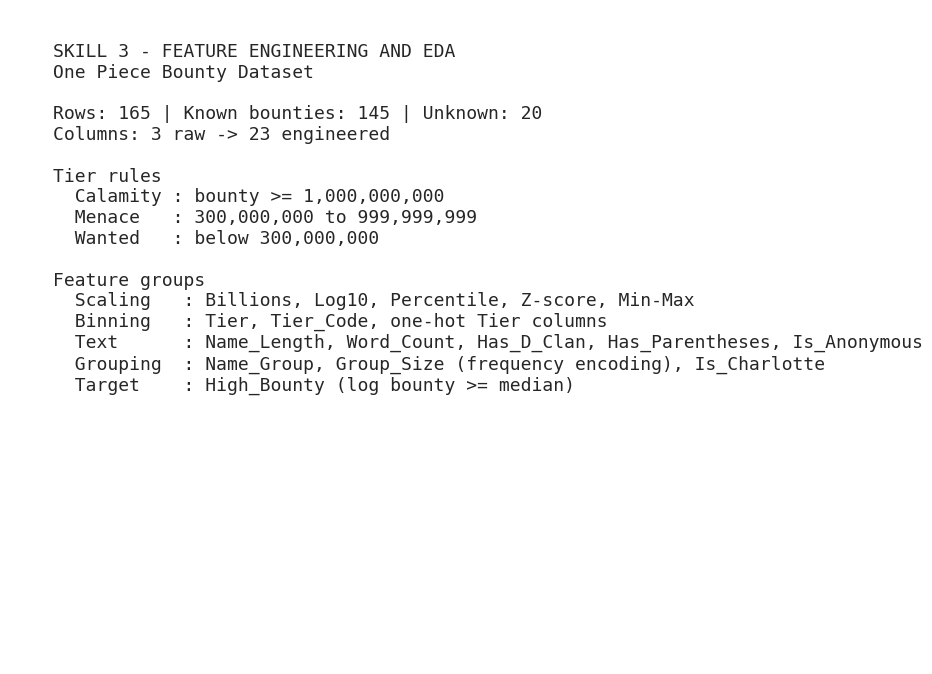

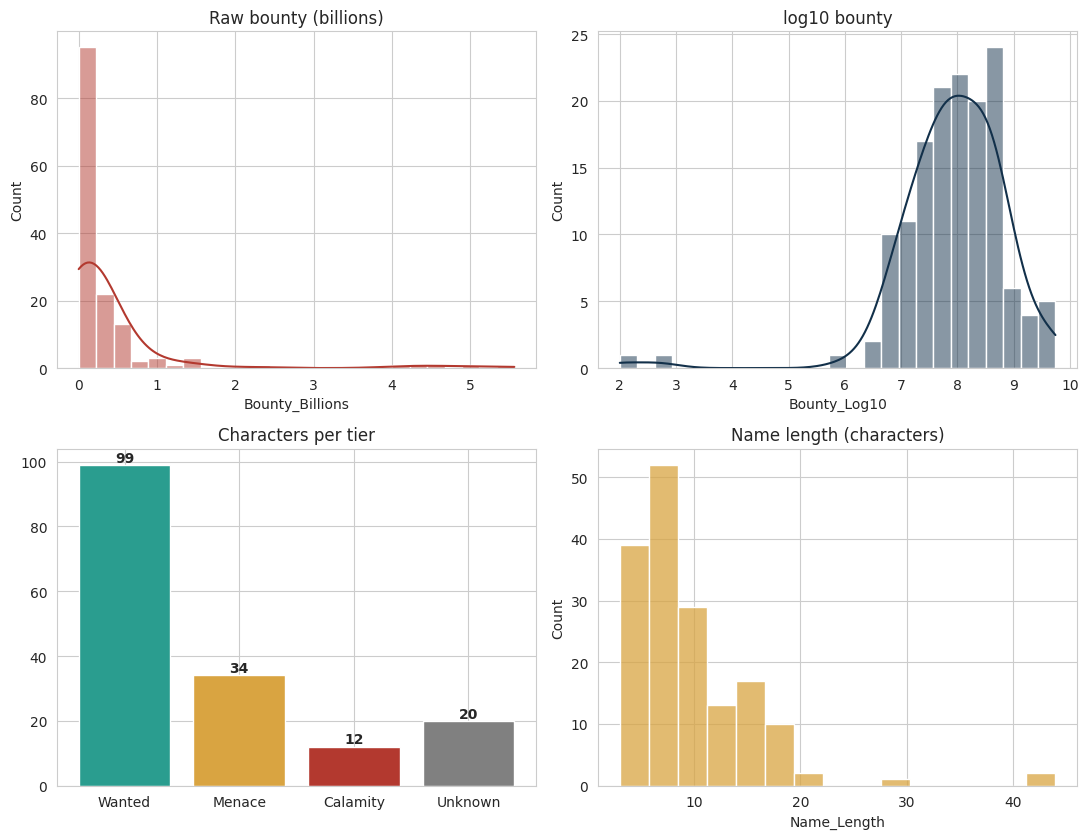

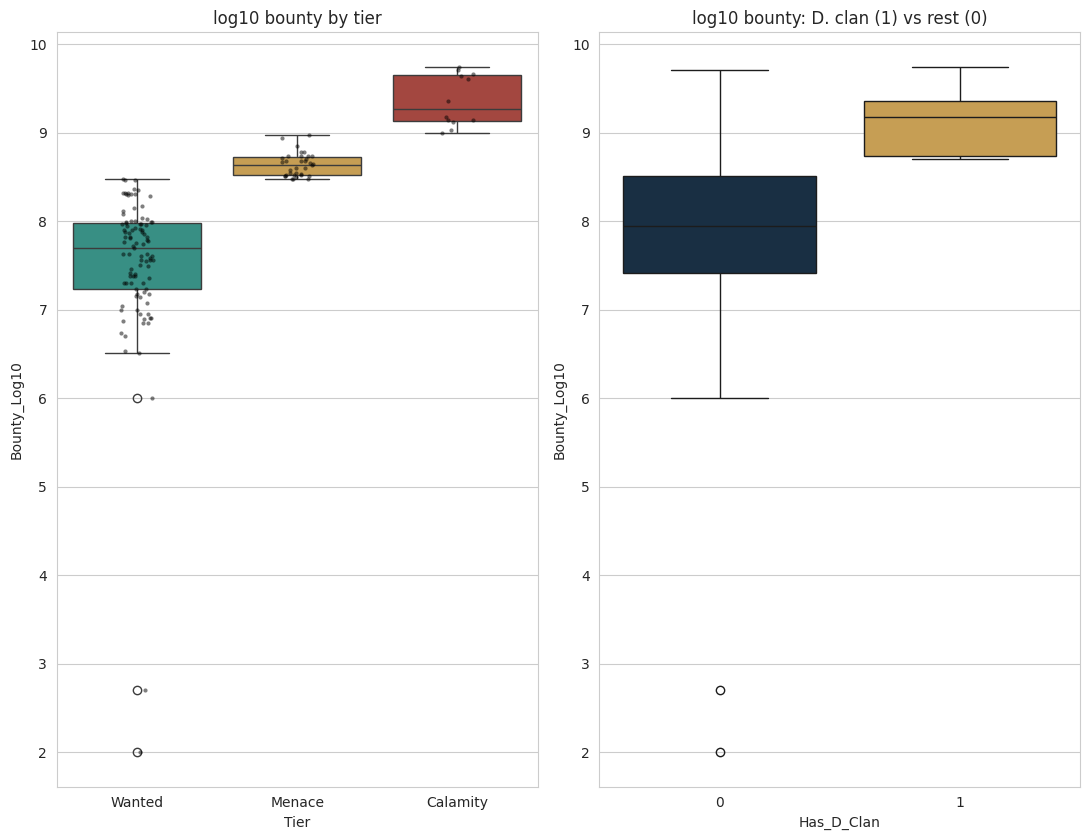

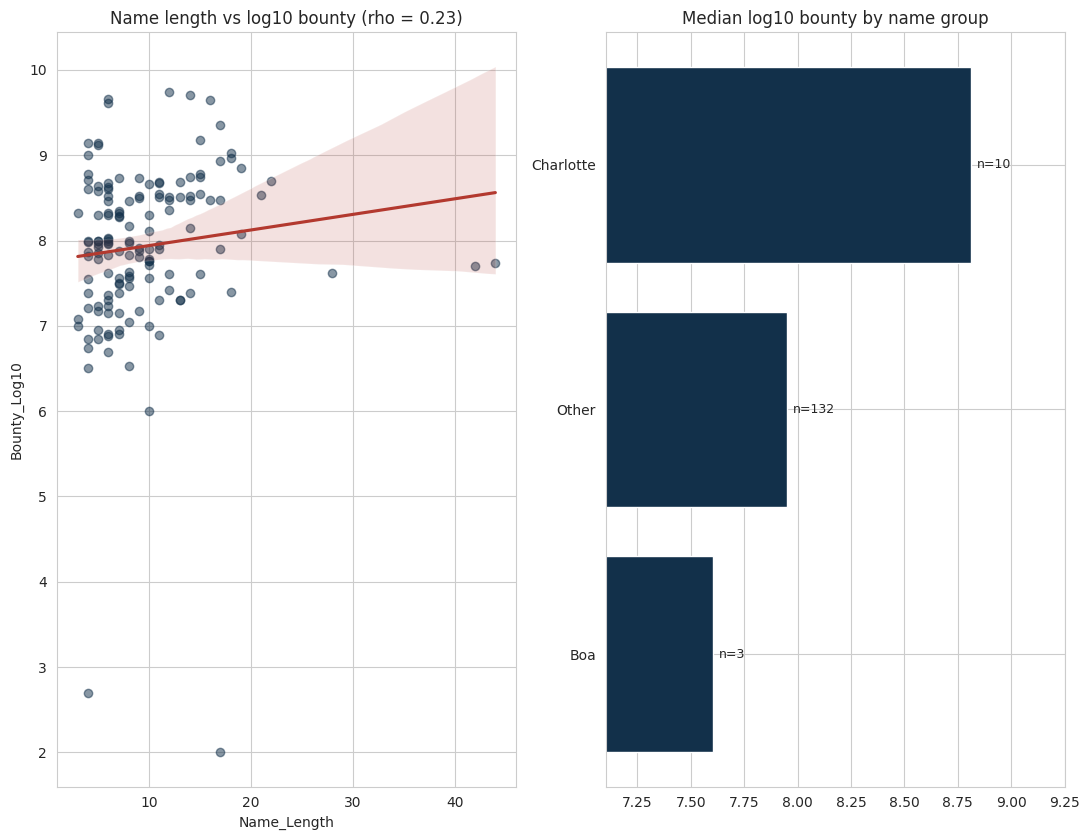

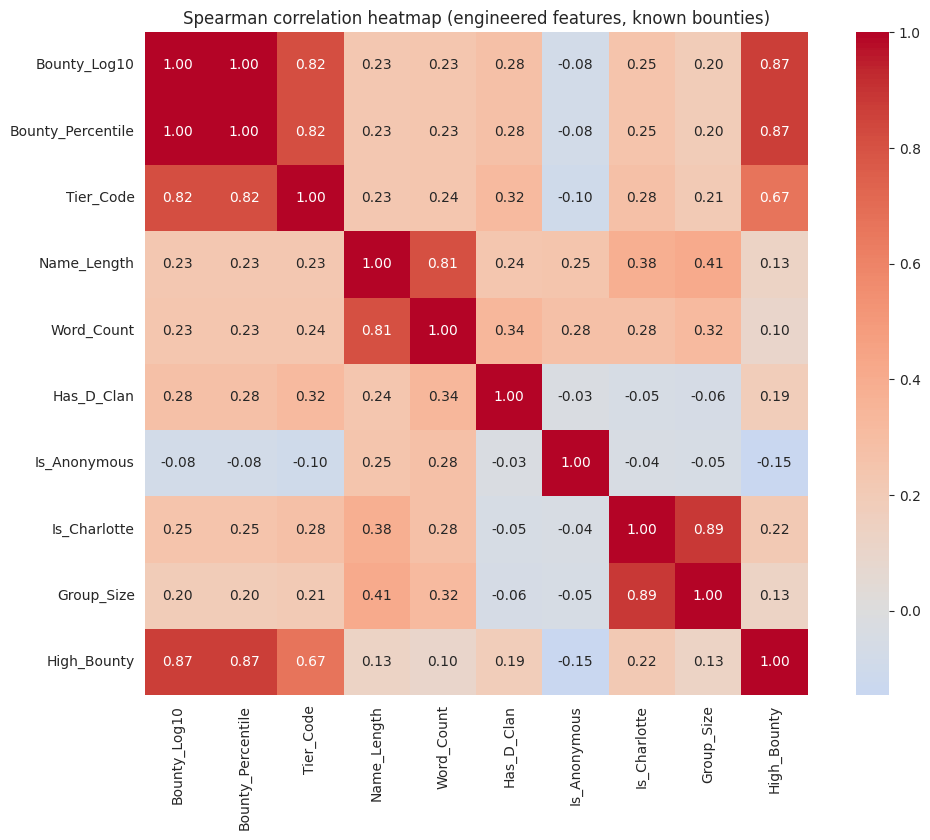

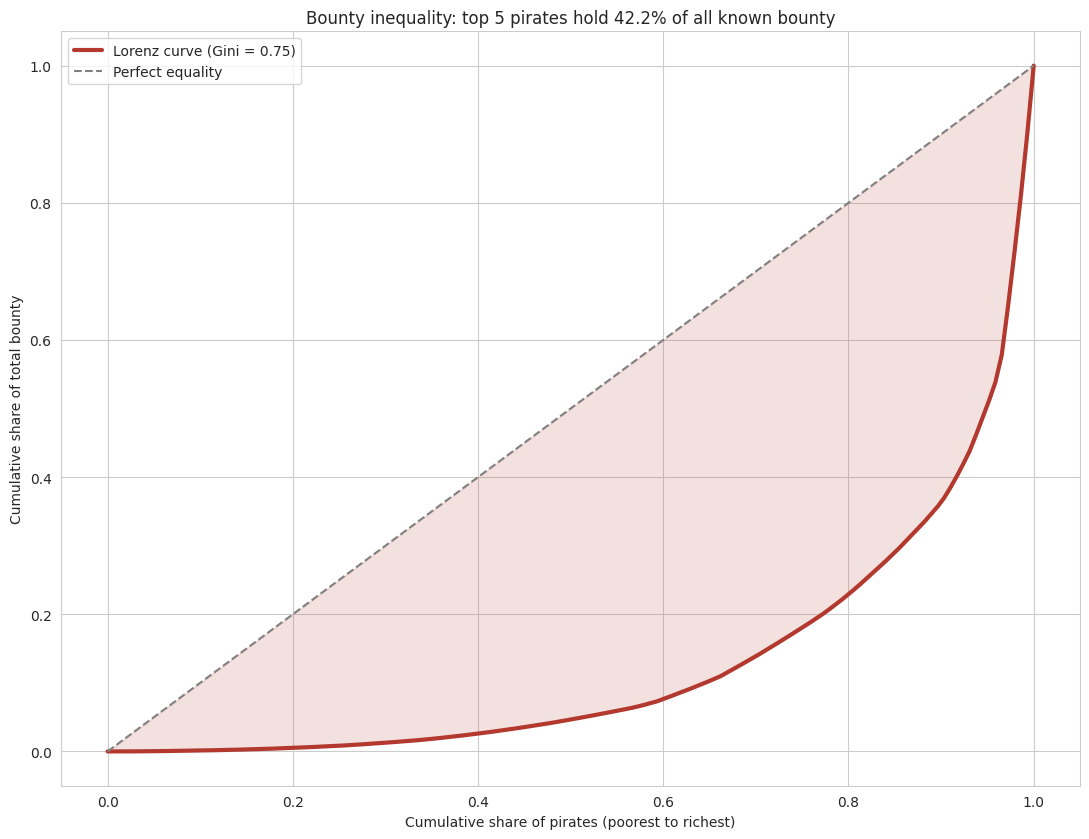

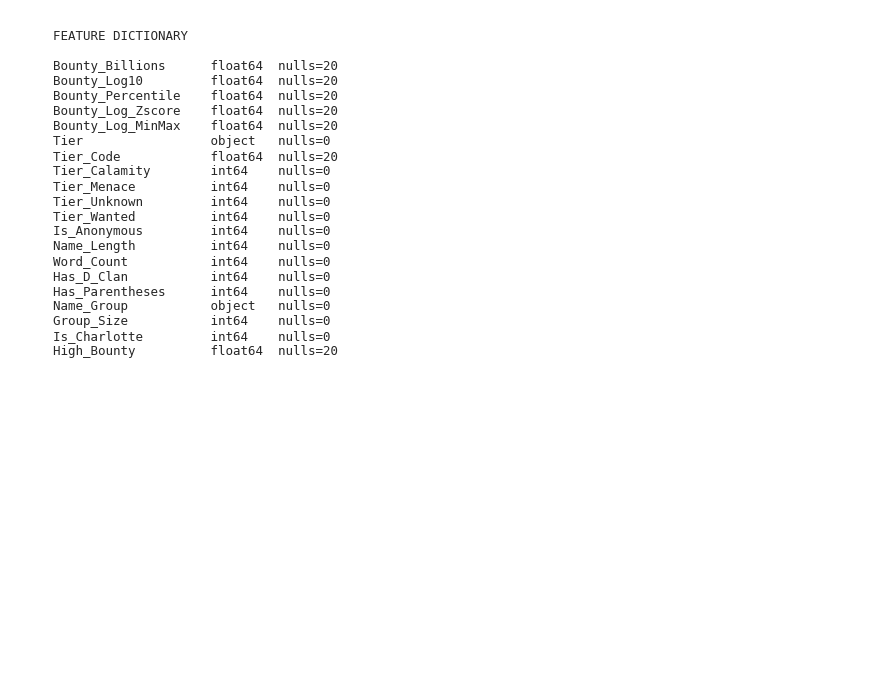


OBSERVATION - SKILL 3

Feature engineering expanded the dataset from 3 raw columns to 23 columns across scaling, binning, text, grouping and target features. Bounties were split into tiers: 12 Calamity, 34 Menace, 99 Wanted and 20 Unknown. 3 entries are anonymous descriptions rather than real names, so they were flagged with Is_Anonymous instead of being dropped. The bounty distribution is very unequal: the Gini coefficient is 0.75, the top 5 characters hold 42.2% of all known bounty and the top 10% hold 64.2%. Among the name-based features, Has_D_Clan has the strongest Spearman correlation with log bounty at 0.28, which means name text alone is only a weak predictor. Tier, percentile and High_Bounty are built from the bounty itself, so they must stay out of the predictor set in the modelling skills. D. clan members have a median log10 bounty of 9.18 compared with 7.95 for the rest, but the D. clan group has only 5 known members, so this is a pattern in a tiny sample and not a proven 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import importlib.util, subprocess, sys, os, re, json, glob, shutil, warnings, unicodedata

for pkg in ["pandas", "numpy", "matplotlib", "seaborn", "plotly"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.backends.backend_pdf import PdfPages

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

CSV_PATH = "/content/OnePiece-Bounty_-_Sheet1.csv"
OUT_DIR = "Skill3_Output"
CALAMITY_MIN = 1_000_000_000
MENACE_MIN = 300_000_000
NAVY, GOLD, RED, TEAL = "#12304a", "#d9a441", "#b3392f", "#2a9d8f"
TIER_ORDER = ["Wanted", "Menace", "Calamity"]
os.makedirs(OUT_DIR, exist_ok=True)


def find_csv():
    if os.path.exists(CSV_PATH):
        return CSV_PATH
    for root in ["/content", "/content/drive", os.getcwd()]:
        for path in glob.glob(os.path.join(root, "**", "*.csv"), recursive=True):
            if "bounty" in os.path.basename(path).lower() and "/sample_data/" not in path:
                return path
    try:
        from google.colab import files
        print("CSV not found on disk - pick OnePiece-Bounty_-_Sheet1.csv in the upload dialog")
        for name in files.upload():
            if name.lower().endswith(".csv"):
                return os.path.abspath(name)
    except ImportError:
        pass
    raise FileNotFoundError("Could not find the One Piece bounty CSV. Set CSV_PATH at the top to its exact path.")


FOUND_PATH = find_csv()
raw = pd.read_csv(FOUND_PATH)
print("CONNECTED TO:", FOUND_PATH)
print("Raw shape:", raw.shape, "| columns:", list(raw.columns))
print(raw.head(5).to_string())
print("Sample raw bounties:", raw["Bounty"].sample(4, random_state=3).tolist())
print("-" * 70)

df = raw.copy()
df.columns = df.columns.str.strip()
df["Name"] = df["Name"].astype(str).map(lambda s: unicodedata.normalize("NFKC", s)).str.replace(r"\s+", " ", regex=True).str.strip()
df = df.drop_duplicates(subset="Name").reset_index(drop=True)
df["Bounty_Berry"] = pd.to_numeric(df["Bounty"].astype(str).str.replace(r"[^\d]", "", regex=True).replace("", np.nan), errors="coerce")
df = df.drop(columns=["S.no", "Bounty"])
df["Bounty_Known"] = df["Bounty_Berry"].notna()
print("Base clean (same rules as Skill-2):", df.shape, "| known:", int(df["Bounty_Known"].sum()), "| unknown:", int((~df["Bounty_Known"]).sum()))

df["Bounty_Billions"] = df["Bounty_Berry"] / 1e9
df["Bounty_Log10"] = np.log10(df["Bounty_Berry"])
df["Bounty_Percentile"] = df["Bounty_Berry"].rank(pct=True) * 100
df["Bounty_Log_Zscore"] = (df["Bounty_Log10"] - df["Bounty_Log10"].mean()) / df["Bounty_Log10"].std()
df["Bounty_Log_MinMax"] = (df["Bounty_Log10"] - df["Bounty_Log10"].min()) / (df["Bounty_Log10"].max() - df["Bounty_Log10"].min())

df["Tier"] = pd.cut(df["Bounty_Berry"], bins=[0, MENACE_MIN - 1, CALAMITY_MIN - 1, np.inf], labels=TIER_ORDER).astype(object)
df["Tier"] = df["Tier"].fillna("Unknown")
df["Tier_Code"] = df["Tier"].map({"Wanted": 0, "Menace": 1, "Calamity": 2})
df = pd.concat([df, pd.get_dummies(df["Tier"], prefix="Tier").astype(int)], axis=1)

df["Is_Anonymous"] = df["Name"].str.startswith("(").astype(int)
df["Name_Length"] = df["Name"].str.len()
df["Word_Count"] = df["Name"].str.split().str.len()
df["Has_D_Clan"] = df["Name"].str.contains(r"\bD\.", regex=True).astype(int)
df["Has_Parentheses"] = df["Name"].str.contains(r"\(", regex=True).astype(int)
first_token = df["Name"].str.split().str[0]
token_counts = first_token.map(first_token.value_counts())
df["Name_Group"] = np.where((token_counts >= 3) & (df["Is_Anonymous"] == 0), first_token, "Other")
df["Group_Size"] = df["Name_Group"].map(df["Name_Group"].value_counts())
df.loc[df["Name_Group"] == "Other", "Group_Size"] = 1
df["Is_Charlotte"] = (df["Name_Group"] == "Charlotte").astype(int)

median_log = df["Bounty_Log10"].median()
df["High_Bounty"] = np.where(df["Bounty_Known"], (df["Bounty_Log10"] >= median_log).astype(float), np.nan)

known = df[df["Bounty_Known"]].copy()
engineered = [c for c in df.columns if c not in ["Name", "Bounty_Berry", "Bounty_Known"]]
print("\nFEATURE ENGINEERING DONE")
print("Columns now:", df.shape[1], "| engineered features:", len(engineered))
print(df.head(8).to_string())
print("\nTier counts:\n", df["Tier"].value_counts().to_string())
print("\nName groups:\n", df["Name_Group"].value_counts().to_string())
print("\nAnonymous entries:", df.loc[df["Is_Anonymous"] == 1, "Name"].tolist())

numeric_cols = ["Bounty_Log10", "Bounty_Percentile", "Tier_Code", "Name_Length", "Word_Count", "Has_D_Clan",
                "Is_Anonymous", "Is_Charlotte", "Group_Size", "High_Bounty"]
corr = known[numeric_cols].corr(method="spearman")
corr_with_bounty = corr["Bounty_Log10"].drop(["Bounty_Log10", "Bounty_Percentile", "Tier_Code", "High_Bounty"]).sort_values(key=abs, ascending=False)
print("\nSpearman correlation with Bounty_Log10:\n", corr_with_bounty.round(3).to_string())

sorted_b = np.sort(known["Bounty_Berry"].values)
cum = np.cumsum(sorted_b) / sorted_b.sum()
lorenz_x = np.insert(np.arange(1, len(sorted_b) + 1) / len(sorted_b), 0, 0)
lorenz_y = np.insert(cum, 0, 0)
gini = float(1 - 2 * np.sum((lorenz_y[1:] + lorenz_y[:-1]) / 2 * np.diff(lorenz_x)))
top5_share = float(sorted_b[-5:].sum() / sorted_b.sum() * 100)
top10pct_share = float(sorted_b[-int(np.ceil(len(sorted_b) * 0.1)):].sum() / sorted_b.sum() * 100)
print(f"\nGini coefficient: {gini:.3f} | top 5 hold {top5_share:.1f}% | top 10% hold {top10pct_share:.1f}% of all known bounty")

group_stats = known.groupby("Has_D_Clan")["Bounty_Log10"].agg(["count", "median", "mean"]).round(3)
charlotte_stats = known.groupby("Is_Charlotte")["Bounty_Log10"].agg(["count", "median", "mean"]).round(3)
tier_stats = known.groupby("Tier")["Bounty_Berry"].agg(["count", "min", "median", "max"]).reindex(TIER_ORDER)
print("\nD. clan vs rest (log10 bounty):\n", group_stats.to_string())
print("\nCharlotte family vs rest (log10 bounty):\n", charlotte_stats.to_string())
print("\nBounty by tier:\n", tier_stats.to_string())

df.to_csv(f"{OUT_DIR}/engineered_onepiece_bounty.csv", index=False)

with PdfPages(f"{OUT_DIR}/skill3_eda_report.pdf") as pdf:
    plt.figure(figsize=(11, 8.5)); plt.axis("off")
    text = "SKILL 3 - FEATURE ENGINEERING AND EDA\nOne Piece Bounty Dataset\n\n"
    text += f"Rows: {len(df)} | Known bounties: {len(known)} | Unknown: {int((~df['Bounty_Known']).sum())}\n"
    text += f"Columns: {raw.shape[1]} raw -> {df.shape[1]} engineered\n\nTier rules\n"
    text += f"  Calamity : bounty >= {CALAMITY_MIN:,}\n  Menace   : {MENACE_MIN:,} to {CALAMITY_MIN - 1:,}\n  Wanted   : below {MENACE_MIN:,}\n\n"
    text += "Feature groups\n  Scaling   : Billions, Log10, Percentile, Z-score, Min-Max\n  Binning   : Tier, Tier_Code, one-hot Tier columns\n"
    text += "  Text      : Name_Length, Word_Count, Has_D_Clan, Has_Parentheses, Is_Anonymous\n"
    text += "  Grouping  : Name_Group, Group_Size (frequency encoding), Is_Charlotte\n  Target    : High_Bounty (log bounty >= median)\n"
    plt.text(0.05, 0.95, text, fontsize=13, va="top", family="monospace")
    pdf.savefig(); plt.show(); plt.close()

    fig, ax = plt.subplots(2, 2, figsize=(11, 8.5))
    sns.histplot(known["Bounty_Billions"], bins=25, kde=True, color=RED, ax=ax[0, 0]); ax[0, 0].set_title("Raw bounty (billions)")
    sns.histplot(known["Bounty_Log10"], bins=25, kde=True, color=NAVY, ax=ax[0, 1]); ax[0, 1].set_title("log10 bounty")
    tc = df["Tier"].value_counts().reindex(TIER_ORDER + ["Unknown"])
    ax[1, 0].bar(tc.index, tc.values, color=[TEAL, GOLD, RED, "grey"]); ax[1, 0].set_title("Characters per tier")
    for i, v in enumerate(tc.values):
        ax[1, 0].text(i, v + 1, str(v), ha="center", fontweight="bold")
    sns.histplot(df["Name_Length"], bins=15, color=GOLD, ax=ax[1, 1]); ax[1, 1].set_title("Name length (characters)")
    plt.tight_layout(); pdf.savefig(); plt.show(); plt.close()

    fig, ax = plt.subplots(1, 2, figsize=(11, 8.5))
    sns.boxplot(data=known, x="Tier", y="Bounty_Log10", order=TIER_ORDER, palette=[TEAL, GOLD, RED], ax=ax[0])
    ax[0].set_title("log10 bounty by tier")
    sns.stripplot(data=known, x="Tier", y="Bounty_Log10", order=TIER_ORDER, color="black", size=3, alpha=0.5, ax=ax[0])
    sns.boxplot(data=known, x="Has_D_Clan", y="Bounty_Log10", palette=[NAVY, GOLD], ax=ax[1])
    ax[1].set_title("log10 bounty: D. clan (1) vs rest (0)")
    plt.tight_layout(); pdf.savefig(); plt.show(); plt.close()

    fig, ax = plt.subplots(1, 2, figsize=(11, 8.5))
    sns.regplot(data=known, x="Name_Length", y="Bounty_Log10", scatter_kws={"alpha": 0.5, "color": NAVY}, line_kws={"color": RED}, ax=ax[0])
    ax[0].set_title(f"Name length vs log10 bounty (rho = {corr.loc['Name_Length', 'Bounty_Log10']:.2f})")
    cs = known.groupby("Name_Group")["Bounty_Log10"].agg(["median", "count"]).sort_values("median", ascending=False)
    ax[1].barh(cs.index[::-1], cs["median"][::-1], color=NAVY)
    for i, (m, c) in enumerate(zip(cs["median"][::-1], cs["count"][::-1])):
        ax[1].text(m + 0.03, i, f"n={c}", va="center", fontsize=9)
    ax[1].set_title("Median log10 bounty by name group"); ax[1].set_xlim(left=cs["median"].min() - 0.5)
    plt.tight_layout(); pdf.savefig(); plt.show(); plt.close()

    plt.figure(figsize=(11, 8.5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title("Spearman correlation heatmap (engineered features, known bounties)")
    plt.tight_layout(); pdf.savefig(); plt.show(); plt.close()

    plt.figure(figsize=(11, 8.5))
    plt.plot(lorenz_x, lorenz_y, color=RED, lw=3, label=f"Lorenz curve (Gini = {gini:.2f})")
    plt.plot([0, 1], [0, 1], "--", color="grey", label="Perfect equality")
    plt.fill_between(lorenz_x, lorenz_y, lorenz_x, color=RED, alpha=0.15)
    plt.title(f"Bounty inequality: top 5 pirates hold {top5_share:.1f}% of all known bounty")
    plt.xlabel("Cumulative share of pirates (poorest to richest)"); plt.ylabel("Cumulative share of total bounty")
    plt.legend(); plt.tight_layout(); pdf.savefig(); plt.show(); plt.close()

    plt.figure(figsize=(11, 8.5)); plt.axis("off")
    text = "FEATURE DICTIONARY\n\n"
    for col in engineered:
        text += f"{col:<20} {str(df[col].dtype):<8} nulls={int(df[col].isna().sum())}\n"
    plt.text(0.05, 0.97, text, fontsize=9, va="top", family="monospace")
    pdf.savefig(); plt.show(); plt.close()

sun = df.copy()
sun["Bounty_Plot"] = sun["Bounty_Berry"].fillna(0) + 1
sun["Label"] = sun["Name"].str.slice(0, 28)
fig = px.sunburst(sun[sun["Bounty_Known"]], path=["Tier", "Name_Group", "Label"], values="Bounty_Plot", color="Bounty_Log10",
                  color_continuous_scale="YlOrRd", title="Grand Line bounty sunburst: Tier > Name group > Pirate (size = bounty)")
fig.update_layout(width=950, height=850)
fig.write_html(f"{OUT_DIR}/bounty_sunburst.html")
fig.show()

parallel = known[["Name", "Bounty_Log10", "Name_Length", "Word_Count", "Has_D_Clan", "Group_Size", "Tier_Code"]]
fig2 = px.parallel_coordinates(parallel, dimensions=["Name_Length", "Word_Count", "Has_D_Clan", "Group_Size", "Tier_Code", "Bounty_Log10"],
                               color="Bounty_Log10", color_continuous_scale="Turbo", title="Parallel coordinates: how engineered features line up with bounty")
fig2.write_html(f"{OUT_DIR}/feature_parallel.html")
fig2.show()

feature_dictionary = pd.DataFrame({
    "Feature": engineered,
    "Dtype": [str(df[c].dtype) for c in engineered],
    "Nulls": [int(df[c].isna().sum()) for c in engineered],
})
feature_dictionary.to_csv(f"{OUT_DIR}/feature_dictionary.csv", index=False)

best_feat = corr_with_bounty.index[0]
insights = (
    "OBSERVATION - SKILL 3\n\n"
    f"Feature engineering expanded the dataset from {raw.shape[1]} raw columns to {df.shape[1]} columns across scaling, binning, text, grouping and target features. "
    f"Bounties were split into tiers: {int((df['Tier'] == 'Calamity').sum())} Calamity, {int((df['Tier'] == 'Menace').sum())} Menace, "
    f"{int((df['Tier'] == 'Wanted').sum())} Wanted and {int((df['Tier'] == 'Unknown').sum())} Unknown. "
    f"{int(df['Is_Anonymous'].sum())} entries are anonymous descriptions rather than real names, so they were flagged with Is_Anonymous instead of being dropped. "
    f"The bounty distribution is very unequal: the Gini coefficient is {gini:.2f}, the top 5 characters hold {top5_share:.1f}% of all known bounty and the top 10% hold {top10pct_share:.1f}%. "
    f"Among the name-based features, {best_feat} has the strongest Spearman correlation with log bounty at {corr_with_bounty.iloc[0]:.2f}, "
    f"which means name text alone is only a weak predictor. Tier, percentile and High_Bounty are built from the bounty itself, so they must stay out of the predictor set in the modelling skills. "
    f"D. clan members have a median log10 bounty of {group_stats.loc[1, 'median']:.2f} compared with {group_stats.loc[0, 'median']:.2f} for the rest, "
    f"but the D. clan group has only {int(group_stats.loc[1, 'count'])} known members, so this is a pattern in a tiny sample and not a proven effect."
)
with open(f"{OUT_DIR}/Observation_Skill_3.txt", "w", encoding="utf-8") as f:
    f.write(insights)
print("\n" + insights)

print("\nFiles created in", OUT_DIR)
for fn in sorted(os.listdir(OUT_DIR)):
    print("  -", fn)

try:
    from google.colab import files
    shutil.make_archive("Skill3_Output", "zip", OUT_DIR)
    files.download("Skill3_Output.zip")
except ImportError:
    pass